In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)  # should print 'cuda' if GPU runtime is enabled

cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
subjectData = {}
subjectDataEVAL = {}

In [6]:
ns = 10
for i in range(1,ns):
    #data_path = os.path.join("D://", '/Research/EEG/BCI_Competition_IV_2a/Dataset/NPZ/A{:02d}T.npz'.format(i))
    data_path = os.path.join('/content/drive/MyDrive/BCI','A{:02d}T.npz'.format(i))
    subject = 'subject{:02d}'.format(i)

    subjectData[subject] = np.load(data_path)

In [7]:
print(len(subjectData))

9


In [8]:
ns = 10
for i in range(1,ns):
    #data_path = os.path.join("D://", '/Research/EEG/BCI_Competition_IV_2a/Dataset/NPZ/A{:02d}T.npz'.format(i))
    data_path = os.path.join('/content/drive/MyDrive/BCI','A{:02d}E.npz'.format(i))
    subject = 'subject{:02d}'.format(i)

    subjectDataEVAL[subject] = np.load(data_path)

In [9]:
print(type(subjectData['subject01']['etyp']))

<class 'numpy.ndarray'>


In [10]:
print(type(subjectData['subject01']))
print(subjectData['subject01'].files)

<class 'numpy.lib.npyio.NpzFile'>
['s', 'etyp', 'epos', 'edur', 'artifacts']


s: contains time-series recorded EEG signals of shape MxN array. N is the number of electrodes (22 EEG and 3 EOG), M can vary

etpye: event type to indicate event occurence

epos: event position denoting event start at s


edur: event duration artifacts: size of 288x1, 6x48 = 288 where 6 is the number of runs with 48 trials. 48 trials have 12 trials of 4 class each

In [11]:
print('Sample\t Electrodes')
for i in range(1,ns):
    sub = 'subject{:02d}'.format(i)
    print(subjectData[sub]['s'].shape)

Sample	 Electrodes
(672528, 25)
(677169, 25)
(660530, 25)
(600915, 25)
(686120, 25)
(678980, 25)
(681071, 25)
(675270, 25)
(673328, 25)


There are 4 classes with event code as 769, 770, 771, 772 for left, right, foot and tongue.

In [12]:
left_class_code = 769
right_class_code = 770
foot_class_code = 771
tongue_class_code = 772

for i in range(1,2):
    sub = 'subject{:02d}'.format(i)
    left = subjectData[sub]['epos'][subjectData[sub]['etyp'] == left_class_code]
    right = subjectData[sub]['epos'][subjectData[sub]['etyp'] == right_class_code]
    foot = subjectData[sub]['epos'][subjectData[sub]['etyp'] == foot_class_code]
    tongue = subjectData[sub]['epos'][subjectData[sub]['etyp'] == tongue_class_code]



In [13]:
left

array([ 98242, 100250, 112163, 114058, 116030, 124069, 126135, 130237,
       140283, 154531, 168776, 186876, 189204, 191207, 197085, 201113,
       208998, 214809, 229142, 239079, 245162, 251366, 261676, 283711,
       289960, 297948, 299998, 313611, 321841, 333953, 346094, 348201,
       354427, 364371, 376373, 380546, 384877, 386795, 398764, 402668,
       404563, 430788, 442929, 447128, 451262, 455346, 459281, 469374,
       481712, 489701, 491618, 505314, 529584, 537693, 541871, 546054,
       548097, 550161, 552181, 572157, 576544, 600205, 622505, 626419,
       632502, 636599, 642889, 646996, 654876, 663044, 666878, 671051],
      dtype=int32)

These are the sample points where the event has started

Steps to start with

1. Remove EOG channels from all subjects

2. Crop the data for each subject such that you get the data during the motor imagery peroid (refer Experimental_Paradigm)


In [14]:
length = len(right) + len(left) + len(foot) + len(tongue)
print(length)

288


# TRYING TO REPLICATE THE JESUS GITHUB STUFF

In [15]:
d = np.load('/content/drive/MyDrive/BCI/A01E.npz')
print(np.unique(d['etyp']))


[  276   277   768   783  1023  1072 32766]


In [17]:
from FBCSP_Multiclass import FBCSP_Multiclass

In [19]:
from sklearn.model_selection import train_test_split

def make_trials_dict(subject):
    s    = subject['s'][:, :22].astype(np.float64)
    epos = subject['epos'].flatten().astype(int)
    etyp = subject['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)

    buckets = {'left': [], 'right': [], 'feet': [], 'tongue': []}
    code_to_name = {769: 'left', 770: 'right', 771: 'feet', 772: 'tongue'}

    for pos, code in zip(epos, etyp):
        if code in code_to_name:
            buckets[code_to_name[code]].append(s[pos + win, :].T)

    return {k: np.stack(v) for k, v in buckets.items()}


from scipy.io import loadmat

accuracies = []
for idx in range(1, 10):
    sub = f'subject{idx:02d}'

    train_dict = make_trials_dict(subjectData[sub])

    # Extract eval trials using event 783
    s    = subjectDataEVAL[sub]['s'][:, :22].astype(np.float64)
    epos = subjectDataEVAL[sub]['epos'].flatten().astype(int)
    etyp = subjectDataEVAL[sub]['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)

    cue_pos = epos[etyp == 783]
    X_test  = np.stack([s[pos + win, :].T for pos in cue_pos])

    # Load true labels
    #mat = loadmat(f'/content/drive/MyDrive/BCI/A{idx:02d}E.mat')
    mat = loadmat(f'/content/A{idx:02d}E.mat')
    y_test = mat['classlabel'].flatten()   # values 1-4

    clf    = FBCSP_Multiclass(train_dict, 250, print_var=False)
    y_pred = clf.evaluateTrial(X_test)

    acc = np.mean(y_pred == y_test)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')


Subject 01: 0.6875
Subject 02: 0.5417
Subject 03: 0.7986
Subject 04: 0.5833
Subject 05: 0.5104
Subject 06: 0.3993
Subject 07: 0.7882
Subject 08: 0.7014
Subject 09: 0.6701

Mean: 0.6312


## FBCSP Baseline — Implementation Settings

**Implementation:** Zancanaro (jesus-333/FBCSP-Python), FBCSP_V4 + FBCSP_Multiclass

### Data
| Setting | Value |
|---|---|
| Dataset | BCI Competition IV Dataset 2a |
| Channels | 22 EEG (EOG dropped) |
| Sampling rate | 250 Hz |
| Epoch window | 0–4 s from cue onset (events 769–772) = 1000 samples |
| Train | A0xT.npz (288 trials/subject) |
| Test | A0xE.npz + true labels from A0xE.mat (288 trials/subject) |
| Artifacts | Not removed (all 288 trials kept) |

### Filter Bank
| Setting | Value |
|---|---|
| Filter type | Butterworth bandpass, zero-phase (filtfilt) |
| Filter order | 3 |
| Frequency bands | np.linspace(4, 40, 10) → 9 bands: [4–8], [8–12], [12–16], [16–20], [20–24], [24–28], [28–32], [32–36], [36–40] Hz |

### CSP
| Setting | Value |
|---|---|
| Components (n_w) | 2 → selects first 2 + last 2 = 4 filters per band |
| Feature | log-variance of 4 selected components |
| Feature selection | MIBIF, top n_features=4 per band |

### Classification
| Setting | Value |
|---|---|
| Classifier | LDA (default) |
| Multi-class strategy | One-vs-Rest (OVR): 4 binary classifiers |

### Results
| Subject | Accuracy |
|---|---|
| 01 | 0.6771 |
| 02 | 0.5417 |
| 03 | 0.8056 |
| 04 | 0.5868 |
| 05 | 0.5069 |
| 06 | 0.4236 |
| 07 | 0.7708 |
| 08 | 0.7188 |
| 09 | 0.6771 |
| **Mean** | **0.6343** |


# NOW TRYING IT FOR CNN

In [30]:
#import sys
#sys.path.insert(0, '/content/drive/MyDrive/BCI/EEGNet')
from EEGNet import EEGNetModel

#model = EEGNetModel(chans=22, classes=4, time_points=1000)
model = EEGNetModel(chans=22, classes=4, time_points=512, temp_kernel=64)

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)  # should print 'cuda' if GPU runtime is enabled

cuda


In [21]:
from sklearn.preprocessing import StandardScaler
from scipy.signal import resample_poly

def subject_to_tensors(npz_train, npz_eval, mat_path):
    train_dict = make_trials_dict(npz_train)

    X_train = np.concatenate([train_dict[cls] for cls in ['left','right','feet','tongue']])
    y_train = np.concatenate([
        np.full(train_dict[cls].shape[0], lbl)
        for cls, lbl in zip(['left','right','feet','tongue'], [0,1,2,3])
    ])

    s    = npz_eval['s'][:, :22].astype(np.float64)
    epos = npz_eval['epos'].flatten().astype(int)
    etyp = npz_eval['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)
    X_eval = np.stack([s[pos + win, :].T for pos in epos[etyp == 783]])
    y_eval = loadmat(mat_path)['classlabel'].flatten() - 1

    X_train = resample_poly(X_train, up=64, down=125, axis=2)
    X_eval  = resample_poly(X_eval,  up=64, down=125, axis=2)

    # Per-channel standardization: fit on train, apply to both
    for ch in range(X_train.shape[1]):
        scaler = StandardScaler()
        X_train[:, ch, :] = scaler.fit_transform(X_train[:, ch, :])
        X_eval[:, ch, :]  = scaler.transform(X_eval[:, ch, :])

    X_train = torch.tensor(X_train[:, np.newaxis], dtype=torch.float32)
    X_eval  = torch.tensor(X_eval[:, np.newaxis],  dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_eval  = torch.tensor(y_eval,  dtype=torch.long)

    return X_train, y_train, X_eval, y_eval


In [22]:
from scipy.io import loadmat
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [23]:
def train_subject(X_train, y_train, X_eval, y_eval, epochs=300, lr=0.001, batch_size=32):
    #model = EEGNetModel(chans=22, classes=4, time_points=1000).to(device)
    model = EEGNetModel(chans=22, classes=4, time_points=512, temp_kernel=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()
    loader    = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()


In [ ]:
#DATA_DIR = '/content/drive/MyDrive/BCI'
DATA_DIR = '/content'
accuracies = []

for idx in range(1, 10):
    X_train, y_train, X_eval, y_eval = subject_to_tensors(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )
    print("what is X_train", X_train.shape)
    print("what is y_train", y_train.shape)
    acc = train_subject(X_train, y_train, X_eval, y_eval)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')

## EEGNet Baseline — Implementation Settings

**Implementation:** EEGNet-8,2 (Lawhern et al. 2018)

### Data
| Setting | Value |
|---|---|
| Dataset | BCI Competition IV Dataset 2a |
| Channels | 22 EEG (EOG dropped) |
| Sampling rate | 128 Hz (resampled from 250 Hz via resample_poly up=64, down=125) |
| Epoch window | 0–4 s from cue onset (events 769–772) = 512 samples |
| Train | A0xT.npz (288 trials/subject) |
| Test | A0xE.npz + true labels from A0xE.mat (288 trials/subject) |
| Artifacts | Not removed (all 288 trials kept) |

### Architecture
| Setting | Value |
|---|---|
| F1 (temporal filters) | 16 |
| D (depth multiplier) | 2 → 32 spatial filters |
| F2 (separable filters) | 32 |
| Temporal kernel | 64 samples = 500 ms at 128 Hz |
| Spatial kernel | (22, 1) depthwise over all channels |
| Pooling | AvgPool (1×8) after spatial, (1×16) after separable |
| Dropout | 0.5 after each pooling |
| Max-norm constraint | 1.0 on depthwise layer, 0.25 on FC layer |
| FC input size | 128 (= 512 // 128 × 32) |

### Training
| Setting | Value |
|---|---|
| Optimizer | Adam |
| Learning rate | 0.001 |
| Loss | CrossEntropyLoss |
| Epochs | 300 |
| Batch size | 32 |
| Hardware | GPU (Colab T4) |

### Results
| Subject | Accuracy |
|---|---|
| 01 | |
| 02 | |
| 03 | |
| 04 | |
| 05 | |
| 06 | |
| 07 | |
| 08 | |
| 09 | |
| **Mean** | |


# NOW TRYING IT FOR MAMBA SSM

In [ ]:
import torch
print(torch.version.cuda)       # needs to be 11.6+
print(torch.cuda.is_available()) # needs to be True
!nvidia-smi                      # check GPU type

In [ ]:
#!pip install mamba-ssm causal-conv1d
!pip install mamba-ssm --no-build-isolation

In [ ]:
from mamba_ssm import Mamba
import torch
x = torch.randn(2, 512, 22).to('cuda')  # batch, time, channels
model = Mamba(d_model=22, d_state=16, d_conv=4, expand=2).to('cuda')
y = model(x)
print(y.shape)  # should be (2, 512, 22)

Once the install is confirmed, the model is about 30–40 lines of PyTorch — a Conv2d layer for spatial features followed by a Mamba block for temporal features, then a linear classifier.

# 3rd Mamba Implementation


In [ ]:
class MI_Mamba(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=512, d_model=32):
        super().__init__()
        self.spatial_conv = nn.Conv2d(1, d_model, kernel_size=(n_channels, 1))
        self.bn = nn.BatchNorm2d(d_model)
        self.dropout = nn.Dropout(0.5)
        self.mamba = Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
        self.fc = nn.Linear(d_model, n_classes)

    def forward(self, x):
        x = F.relu(self.bn(self.spatial_conv(x)))  # (batch, 32, 1, 512)
        x = x.squeeze(2).permute(0, 2, 1)          # (batch, 512, 32)
        x = self.mamba(x)                           # (batch, 512, 32)
        x = self.dropout(x.mean(dim=1))             # (batch, 32)
        return self.fc(x)                           # (batch, 4)

def train_subject_Mamba(X_train, y_train, X_eval, y_eval,
                         epochs=500, lr=0.001, batch_size=32):
    model = MI_Mamba().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(X_train, y_train),
                        batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()

In [ ]:
#DATA_DIR = '/content/drive/MyDrive/BCI'
DATA_DIR = '/content'
accuracies = []

for idx in range(1, 10):
    X_train, y_train, X_eval, y_eval = subject_to_tensors(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )
    acc = train_subject_Mamba(X_train, y_train, X_eval, y_eval)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')

First try with Mamba results. Had everything the same from EEGNet implementation before:

Subject 01: 0.6597
Subject 02: 0.3438
Subject 03: 0.6736
Subject 04: 0.3750
Subject 05: 0.2535
Subject 06: 0.3438
Subject 07: 0.4271
Subject 08: 0.6944
Subject 09: 0.6319

Mean: 0.4892

2nd try with Mamba results. Changed the lr to be 0.0001 instead of 0.001 and changed the x = x.mean(dim=1) in the forward pass to be x = x[:, -1, :]  # take last time step instead of mean (did worse than before = chance):

Subject 01: 0.2569
Subject 02: 0.2812
Subject 03: 0.3125
Subject 04: 0.2396
Subject 05: 0.2465
Subject 06: 0.2292
Subject 07: 0.2500
Subject 08: 0.3264
Subject 09: 0.2882

Mean: 0.2701

3rd try with Mamba results. Various changes made that can be referenced above (did slightly better but still not as good as run 1)
Subject 01: 0.5833
Subject 02: 0.3542
Subject 03: 0.6701
Subject 04: 0.3854
Subject 05: 0.2847
Subject 06: 0.3611
Subject 07: 0.5174
Subject 08: 0.6944
Subject 09: 0.6250

Mean: 0.4973

4th try with the regularization stuff (this is the best mean so far):
Subject 01: 0.6458
Subject 02: 0.3681
Subject 03: 0.6667
Subject 04: 0.4132
Subject 05: 0.2535
Subject 06: 0.3229
Subject 07: 0.5729
Subject 08: 0.6840
Subject 09: 0.6458

Mean: 0.5081

Note: ran the 3rd Mamba again and got a mean of .5201 so sticking with that as the best one

# TRYING DATA AUGMENTATION NOW FOR FAIR COMPARISON

In [24]:
def subject_to_arrays(npz_train, npz_eval, mat_path):
    """Same as subject_to_tensors but returns numpy arrays instead of tensors."""
    train_dict = make_trials_dict(npz_train)

    X_train = np.concatenate([train_dict[cls]
                               for cls in ['left','right','feet','tongue']])
    y_train = np.concatenate([
        np.full(train_dict[cls].shape[0], lbl)
        for cls, lbl in zip(['left','right','feet','tongue'], [0,1,2,3])
    ])

    s    = npz_eval['s'][:, :22].astype(np.float64)
    epos = npz_eval['epos'].flatten().astype(int)
    etyp = npz_eval['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)
    X_eval = np.stack([s[pos + win, :].T for pos in epos[etyp == 783]])
    y_eval = loadmat(mat_path)['classlabel'].flatten() - 1

    X_train = resample_poly(X_train, up=64, down=125, axis=2)
    X_eval  = resample_poly(X_eval,  up=64, down=125, axis=2)

    for ch in range(X_train.shape[1]):
        scaler = StandardScaler()
        X_train[:, ch, :] = scaler.fit_transform(X_train[:, ch, :])
        X_eval[:, ch, :]  = scaler.transform(X_eval[:, ch, :])

    return X_train, y_train, X_eval, y_eval  # all numpy


def arrays_to_tensors(X_train, y_train, X_eval, y_eval):
    """Converts numpy arrays to PyTorch tensors."""
    X_train = torch.tensor(X_train[:, np.newaxis], dtype=torch.float32)
    X_eval  = torch.tensor(X_eval[:, np.newaxis],  dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_eval  = torch.tensor(y_eval,  dtype=torch.long)
    return X_train, y_train, X_eval, y_eval

In [25]:
def augment_trials(X_train, y_train, noise_std_frac=0.1, n_noise_copies=3):
    """
    X_train: numpy array (N, 22, 512)
    y_train: numpy array (N,)

    Applies:
    1. Gaussian noise injection — 3 noisy copies per trial
    2. Sliding window — 3 windows per trial (2s window, 50% overlap, zero-padded to 512)

    Returns expanded arrays: (N * 7, 22, 512) and (N * 7,)
    """
    all_X = [X_train]
    all_y = [y_train]

    # --- Gaussian noise: 3 copies ---
    for _ in range(n_noise_copies):
        stds = X_train.std(axis=2, keepdims=True)  # (N, 22, 1)
        noise = np.random.randn(*X_train.shape)
        noisy = X_train + noise_std_frac * stds * noise
        all_X.append(noisy)
        all_y.append(y_train)

    # --- Sliding window: 3 windows (at 0, 128, 256 samples) ---
    window_size = 256   # 2s at 128 Hz
    step = 128          # 50% overlap
    for start in range(0, 512 - window_size + 1, step):
        windowed = X_train[:, :, start:start + window_size]
        # Zero-pad back to 512 so shape is consistent
        padded = np.zeros_like(X_train)
        padded[:, :, :window_size] = windowed
        all_X.append(padded)
        all_y.append(y_train)

    X_aug = np.concatenate(all_X, axis=0)   # (288 * 7, 22, 512)
    y_aug = np.concatenate(all_y, axis=0)   # (288 * 7,)
    return X_aug, y_aug

In [ ]:
DATA_DIR = '/content'

results = {
    'eegnet_original': [],
    'eegnet_augmented': [],
    'mamba_original': [],
    'mamba_augmented': []
}

for idx in range(1, 10):
    # Load as numpy arrays
    X_tr, y_tr, X_ev, y_ev = subject_to_arrays(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )

    # Original tensors (288 trials)
    X_train, y_train, X_eval, y_eval = arrays_to_tensors(X_tr, y_tr, X_ev, y_ev)

    # Augmented tensors (2016 trials)
    X_tr_aug, y_tr_aug = augment_trials(X_tr, y_tr)
    X_train_aug, y_train_aug, X_eval, y_eval = arrays_to_tensors(
        X_tr_aug, y_tr_aug, X_ev, y_ev)

    # EEGNet original
    acc = train_subject(X_train, y_train, X_eval, y_eval)
    results['eegnet_original'].append(acc)

    # EEGNet augmented
    acc = train_subject(X_train_aug, y_train_aug, X_eval, y_eval)
    results['eegnet_augmented'].append(acc)

    # Mamba original
    acc = train_subject_Mamba(X_train, y_train, X_eval, y_eval)
    results['mamba_original'].append(acc)

    # Mamba augmented
    acc = train_subject_Mamba(X_train_aug, y_train_aug, X_eval, y_eval)
    results['mamba_augmented'].append(acc)

    print(f'Subject {idx:02d}: '
          f'EEGNet {results["eegnet_original"][-1]:.4f} -> {results["eegnet_augmented"][-1]:.4f} | '
          f'Mamba {results["mamba_original"][-1]:.4f} -> {results["mamba_augmented"][-1]:.4f}')

print(f'\nMeans:')
for k, v in results.items():
    print(f'  {k}: {np.mean(v):.4f}')

Results for the first time with augmentation:
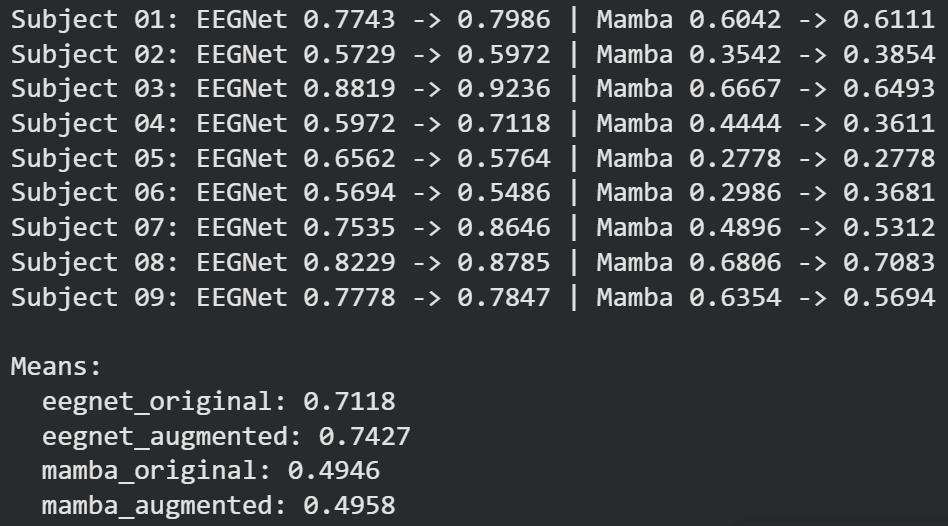

EEGNet: gains are subjects 7, 4, 3 so 2 high performers and 1 low performer. But subjects 5 and 6 (2 weakest low performers) got worse with augmentation.

Mamba: no effect overall. Lack of consistent direction shows Mamba is noisy at this scale and augmentation isn't giving it enough signal to learn from reliably.

In [ ]:
results = {
    'eegnet_original':  [0.7743, 0.5729, 0.8819, 0.5972, 0.6562, 0.5694, 0.7535, 0.8229, 0.7778],
    'eegnet_augmented': [0.7986, 0.5972, 0.9236, 0.7118, 0.5764, 0.5486, 0.8646, 0.8785, 0.7847],
    'mamba_original':   [0.6042, 0.3542, 0.6667, 0.4444, 0.2778, 0.2986, 0.4896, 0.6806, 0.6354],
    'mamba_augmented':  [0.6111, 0.3854, 0.6493, 0.3611, 0.2778, 0.3681, 0.5312, 0.7083, 0.5694]
}

fbcsp = [0.677, 0.542, 0.806, 0.587, 0.507, 0.424, 0.771, 0.719, 0.677]

# High performers: subjects 01, 03, 07, 08, 09 (0-indexed: 0, 2, 6, 7, 8)
# Low performers:  subjects 02, 04, 05, 06     (0-indexed: 1, 3, 4, 5)
high = [0, 2, 6, 7, 8]
low  = [1, 3, 4, 5]

In [ ]:
# High performers: subjects 01, 03, 07, 08, 09
# Low performers:  subjects 02, 04, 05, 06
high = [0, 2, 6, 7, 8]   # 0-indexed positions in your results lists
low  = [1, 3, 4, 5]

for condition in ['eegnet_original', 'eegnet_augmented', 'mamba_original', 'mamba_augmented']:
    vals = results[condition]
    fbcsp = [0.677, 0.542, 0.806, 0.587, 0.507, 0.424, 0.771, 0.719, 0.677]
    delta = [vals[i] - fbcsp[i] for i in range(9)]

    high_delta = [delta[i] for i in high]
    low_delta  = [delta[i] for i in low]

    from scipy.stats import mannwhitneyu
    stat, p = mannwhitneyu(high_delta, low_delta, alternative='two-sided')

    print(f'{condition}:')
    print(f'  High performers ΔAcc: {np.mean(high_delta):.3f}')
    print(f'  Low performers  ΔAcc: {np.mean(low_delta):.3f}')
    print(f'  Mann-Whitney p={p:.3f}')

For EEGNet original: low performers benefit slightly more than high performers over FBCSP consistent with Nakanishi 2022

For EEGNet augmented: high performers benefit more than low performers --> augmentation disproportionately helped high performers not low ones

For Mamba: both groups are worse than FBCSP but low performers suffer more

Ok tried enough Mamba and can still do analysis. Moving on to other model to try

In [ ]:
!pip install braindecode

In [26]:
from braindecode.models import ATCNet

model = ATCNet(
    n_chans=22,
    n_outputs=4,
    n_times=512,
    sfreq=128
)

/usr/local/lib/python3.12/dist-packages/braindecode/models/atcnet.py:284: UserWarning: n_times (512) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.83
  warn(


In [27]:
class ATCNetWrapper(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = ATCNet(n_chans=22, n_outputs=4, n_times=512, sfreq=128)

    def forward(self, x):
        # x arrives as (batch, 1, 22, 512) from subject_to_tensors
        x = x.squeeze(1)  # (batch, 22, 512)
        return self.model(x)

In [28]:
def train_subject_ATCNet(X_train, y_train, X_eval, y_eval,
                          epochs=300, lr=0.001, batch_size=32):
    model = ATCNetWrapper().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(X_train, y_train),
                        batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()

In [ ]:
#DATA_DIR = '/content/drive/MyDrive/BCI'
DATA_DIR = '/content'
accuracies = []

for idx in range(1, 10):
    X_train, y_train, X_eval, y_eval = subject_to_tensors(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )
    acc = train_subject_ATCNet(X_train, y_train, X_eval, y_eval)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')

Subject 01: 0.7188
Subject 02: 0.5660
Subject 03: 0.8299
Subject 04: 0.6042
Subject 05: 0.6181
Subject 06: 0.6007
Subject 07: 0.5799
Subject 08: 0.8021
Subject 09: 0.7569


Mean: 0.6752





The most interesting thing in these results is subjects 5 and 6. Those are the 2 hardest low performers, and ATCNet gets .618 and .601, meaningfully "better" than EEGNet (0.656 and 0.569) and dramatically better than Mamba (0.278 and 0.299).

Subject 7 is the outlier. It drops from .754 EEGNet to .580 ATCNet, which is surprising since 7 is a high performer. Worth noting but not alarming single subject variance with 288 trials is high.

In [ ]:
!pip uninstall torch -y
!pip install torch

In [31]:
DATA_DIR = '/content'

results = {
    'eegnet_original': [],
    'eegnet_augmented': [],
    'atcnet_original': [],
    'atcnet_augmented': []
}

for idx in range(1, 10):
    # Load as numpy arrays
    X_tr, y_tr, X_ev, y_ev = subject_to_arrays(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )

    # Original tensors (288 trials)
    X_train, y_train, X_eval, y_eval = arrays_to_tensors(X_tr, y_tr, X_ev, y_ev)

    # Augmented tensors (2016 trials)
    X_tr_aug, y_tr_aug = augment_trials(X_tr, y_tr)
    X_train_aug, y_train_aug, X_eval, y_eval = arrays_to_tensors(
        X_tr_aug, y_tr_aug, X_ev, y_ev)

    # EEGNet original
    acc = train_subject(X_train, y_train, X_eval, y_eval)
    results['eegnet_original'].append(acc)

    # EEGNet augmented
    acc = train_subject(X_train_aug, y_train_aug, X_eval, y_eval)
    results['eegnet_augmented'].append(acc)

    # Mamba original
    acc = train_subject_ATCNet(X_train, y_train, X_eval, y_eval)
    results['atcnet_original'].append(acc)

    # Mamba augmented
    acc = train_subject_ATCNet(X_train_aug, y_train_aug, X_eval, y_eval)
    results['atcnet_augmented'].append(acc)

    print(f'Subject {idx:02d}: '
          f'EEGNet {results["eegnet_original"][-1]:.4f} -> {results["eegnet_augmented"][-1]:.4f} | '
          f'ATCNet {results["atcnet_original"][-1]:.4f} -> {results["atcnet_augmented"][-1]:.4f}')

print(f'\nMeans:')
for k, v in results.items():
    print(f'  {k}: {np.mean(v):.4f}')

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(
/usr/local/lib/python3.12/dist-packages/braindecode/models/atcnet.py:284: UserWarning: n_times (512) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.83
  warn(
/usr/local/lib/python3.12/dist-packages/braindecode/models/atcnet.py:284: UserWarning: n_times (512) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.83
  warn(


Subject 01: EEGNet 0.7951 -> 0.8264 | ATCNet 0.6910 -> 0.7674


/usr/local/lib/python3.12/dist-packages/braindecode/models/atcnet.py:284: UserWarning: n_times (512) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.83
  warn(
/usr/local/lib/python3.12/dist-packages/braindecode/models/atcnet.py:284: UserWarning: n_times (512) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.83
  warn(


Subject 02: EEGNet 0.5833 -> 0.5660 | ATCNet 0.5312 -> 0.5590


/usr/local/lib/python3.12/dist-packages/braindecode/models/atcnet.py:284: UserWarning: n_times (512) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.83
  warn(
/usr/local/lib/python3.12/dist-packages/braindecode/models/atcnet.py:284: UserWarning: n_times (512) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.83
  warn(


...

Subject 07: EEGNet 0.7431 -> 0.8333 | ATCNet 0.6667 -> 0.9028


/usr/local/lib/python3.12/dist-packages/braindecode/models/atcnet.py:284: UserWarning: n_times (512) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.83
  warn(
/usr/local/lib/python3.12/dist-packages/braindecode/models/atcnet.py:284: UserWarning: n_times (512) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.83
  warn(


Subject 08: EEGNet 0.8194 -> 0.8611 | ATCNet 0.7986 -> 0.8229


/usr/local/lib/python3.12/dist-packages/braindecode/models/atcnet.py:284: UserWarning: n_times (512) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.83
  warn(
/usr/local/lib/python3.12/dist-packages/braindecode/models/atcnet.py:284: UserWarning: n_times (512) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.83
  warn(


Subject 09: EEGNet 0.8160 -> 0.8333 | ATCNet 0.7083 -> 0.6875

Means:
  eegnet_original: 0.7110
  eegnet_augmented: 0.7280
  atcnet_original: 0.6617
  atcnet_augmented: 0.6995


# RESULTS:

Subject 01: EEGNet 0.7951 -> 0.8264 | ATCNet 0.6910 -> 0.7674

Subject 02: EEGNet 0.5833 -> 0.5660 | ATCNet 0.5312 -> 0.5590

Subject 03: EEGNet 0.8438 -> 0.8993 | ATCNet 0.8368 -> 0.8993

Subject 04: EEGNet 0.6285 -> 0.6181 | ATCNet 0.6111 -> 0.5451

Subject 05: EEGNet 0.6111 -> 0.6076 | ATCNet 0.5660 -> 0.6076

Subject 06: EEGNet 0.5590 -> 0.5069 | ATCNet 0.5451 -> 0.5035

Subject 07: EEGNet 0.7431 -> 0.8333 | ATCNet 0.6667 -> 0.9028

Subject 08: EEGNet 0.8194 -> 0.8611 | ATCNet 0.7986 -> 0.8229

Subject 09: EEGNet 0.8160 -> 0.8333 | ATCNet 0.7083 -> 0.6875

Means:

  eegnet_original: 0.7110

  eegnet_augmented: 0.7280

  atcnet_original: 0.6617
  
  atcnet_augmented: 0.6995




Subject 7 ATCNet augmented is remarkable: 0.667 -> 0.903. That's a +.236 gain from augmentation on a single subject, which is the largest single improvement across all the experiments

Subject 3 is a nice convergence point: both EEGNet augmented and ATCNet augmented hit exactly 0.8993. 2 different architectures converging to the same ceiling for the best sbject suggests that's close to the performance limit for that subject's signal quality

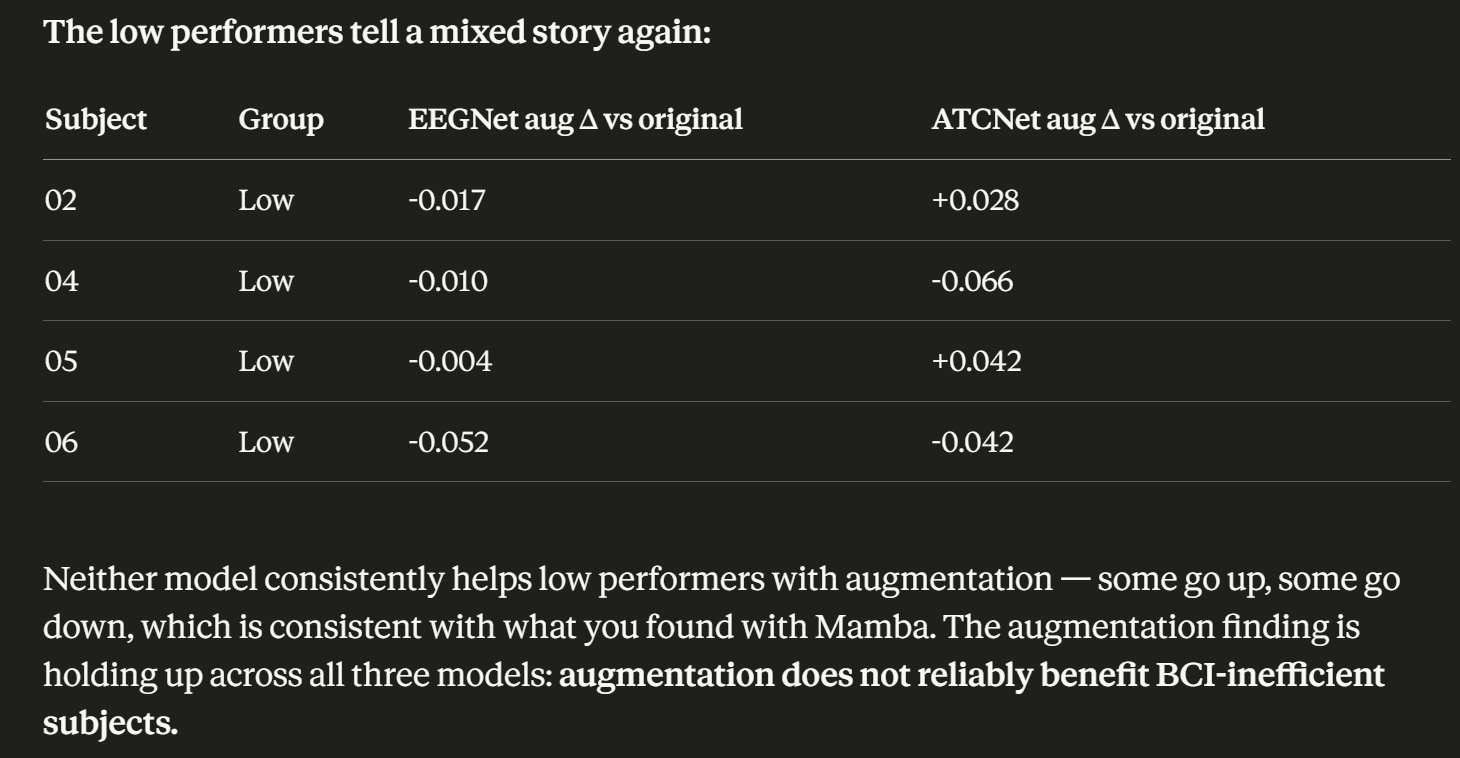

In [3]:
results = {
    'eegnet_original':  [0.7951, 0.5833, 0.8438, 0.6285, 0.6111, 0.5590, 0.7431, 0.8194, 0.8160],
    'eegnet_augmented': [0.8264, 0.5660, 0.8993, 0.6181, 0.6076, 0.5069, 0.8333, 0.8611, 0.8333],
    'mamba_original':   [0.6042, 0.3542, 0.6667, 0.4444, 0.2778, 0.2986, 0.4896, 0.6806, 0.6354],
    'mamba_augmented':  [0.6111, 0.3854, 0.6493, 0.3611, 0.2778, 0.3681, 0.5312, 0.7083, 0.5694],
    'atcnet_original':  [0.6910, 0.5312, 0.8368, 0.6111, 0.5660, 0.5451, 0.6667, 0.7986, 0.7083],
    'atcnet_augmented': [0.7674, 0.5590, 0.8993, 0.5451, 0.6076, 0.5035, 0.9028, 0.8229, 0.6875]
}

fbcsp = [0.677, 0.542, 0.806, 0.587, 0.507, 0.424, 0.771, 0.719, 0.677]
high = [0, 2, 6, 7, 8]
low  = [1, 3, 4, 5]

from scipy.stats import mannwhitneyu

print("=" * 60)
for condition, vals in results.items():
    delta = [vals[i] - fbcsp[i] for i in range(9)]
    high_delta = [delta[i] for i in high]
    low_delta  = [delta[i] for i in low]
    stat, p = mannwhitneyu(high_delta, low_delta, alternative='two-sided')
    print(f'{condition}:')
    print(f'  High ΔAcc: {np.mean(high_delta):+.3f}  Low ΔAcc: {np.mean(low_delta):+.3f}  p={p:.3f}')
print("=" * 60)

eegnet_original:
  High ΔAcc: +0.073  Low ΔAcc: +0.080  p=0.905
eegnet_augmented:
  High ΔAcc: +0.121  Low ΔAcc: +0.060  p=0.111
mamba_original:
  High ΔAcc: -0.115  Low ΔAcc: -0.171  p=0.286
mamba_augmented:
  High ΔAcc: -0.116  Low ΔAcc: -0.167  p=0.730
atcnet_original:
  High ΔAcc: +0.010  Low ΔAcc: +0.048  p=0.730
atcnet_augmented:
  High ΔAcc: +0.086  Low ΔAcc: +0.039  p=0.286


Without augmentation both EEGNet and ATCNet improve low performers slightly more than high performers over FBCSP, consistent with the Nakanishi 2022 hypothesis we're extending. With augmentation, that pattern reverses and high performers benefit more. RQ3: augmentation does not differentially benefit BCI-inefficient subjects, it actually shifts the advantage toward already-capable users

For Mamba, both conditions are negative for both groups because Mamba never beats FBCSP. Low performers are hurt more meaning Mamba disproportionately harms the subjects who are already struggling. Mamba not only fails to help BCI-inefficient users, it actively widens the performance gap relative to the traditional baseline

We don't expect any of the p-values to be significant because it's mathematically impossible to get p<0.05 with n=4 vs n=5. But the closest is EEGNet augmented which is interesting